Loading weights: 100%|██████████| 105/105 [00:00<00:00, 6169.65it/s]


Graph compiled successfully.


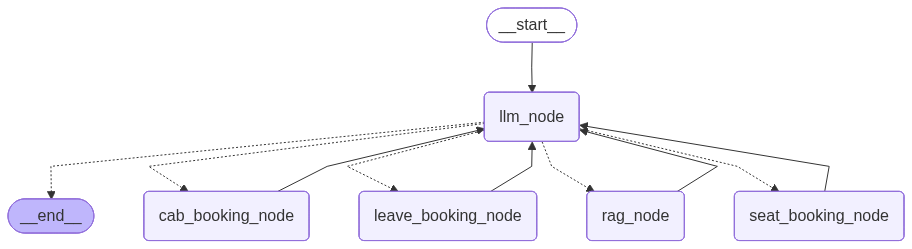

In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../../..')))

from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode
from langchain.chat_models import init_chat_model

from typing import Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from IPython.display import Image, display

load_dotenv()

# Import tools
from app.AIAgent.BookLeave.book_leave_tool import book_leave_tool
from app.AIAgent.CabBooking.cab_booking_tool import cab_booking
from app.AIAgent.SeatBooking.seat_booking_tool import seat_booking
from app.AIAgent.RAG.rag_tool import ask_rag

# State
class State(TypedDict):
    messages: Annotated[list, add_messages]

# LLM with tools bound
tools = [book_leave_tool, cab_booking, seat_booking, ask_rag]

llm = init_chat_model(
    model=os.getenv("OPEN_AI_MODEL"),
    api_key=os.getenv("OPENAI_API_KEY")
)
llm_with_tools = llm.bind_tools(tools)

# Node functions
def llm_node(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Routing function
def route_tools(state: State) -> str:
    """Route to the appropriate tool node based on the last tool call, or END."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_name = last_message.tool_calls[0]["name"]
        routing = {
            "book_leave_tool": "leave_booking_node",
            "cab_booking": "cab_booking_node",
            "seat_booking": "seat_booking_node",
            "ask_rag": "rag_node",
        }
        return routing.get(tool_name, END)
    return END

# Individual ToolNodes
leave_booking_node = ToolNode([book_leave_tool])
cab_booking_node = ToolNode([cab_booking])
seat_booking_node = ToolNode([seat_booking])
rag_node = ToolNode([ask_rag])
single_tool_nodes = [book_leave_tool, cab_booking, seat_booking, ask_rag]

# Build graph
graph = StateGraph(State)

graph.add_node("llm_node", llm_node)
graph.add_node("leave_booking_node", leave_booking_node)
graph.add_node("cab_booking_node", cab_booking_node)
graph.add_node("seat_booking_node", seat_booking_node)
graph.add_node("rag_node", rag_node)

# Entry point
graph.add_edge(START, "llm_node")

# Conditional routing: LLM -> appropriate tool node or END
graph.add_conditional_edges(
    "llm_node",
    route_tools,
    {
        "leave_booking_node": "leave_booking_node",
        "cab_booking_node": "cab_booking_node",
        "seat_booking_node": "seat_booking_node",
        "rag_node": "rag_node",
        END: END,
    },
)

# Each tool node loops back to the LLM for a final answer
graph.add_edge("leave_booking_node", "llm_node")
graph.add_edge("cab_booking_node", "llm_node")
graph.add_edge("seat_booking_node", "llm_node")
graph.add_edge("rag_node", "llm_node")

app = graph.compile()
print("Graph compiled successfully.")

# Display graph image in notebook
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render graph image:", e)



In [ ]:
if __name__ == "__main__":
    # Example user query that may require multiple tools
    user_query = "I want to book leave for next week, and also find a cab to the airport on Friday."
    final_response = app.invoke({"messages": [user_query]})
    print("Final response from graph:", final_response)
